Dataset: HBN
Canales: 8

Cargando Training desde: /home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Training/8/
  - 2496 train
  - 624 validation
Cargando Test desde: /home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Test/8/
  - 840 test
Epoch [1/50] - Train: 52.36% | Val: 49.36% | Test: 50.00%
Epoch [2/50] - Train: 53.53% | Val: 50.96% | Test: 49.52%
Epoch [3/50] - Train: 55.81% | Val: 49.68% | Test: 48.69%
Epoch [4/50] - Train: 57.49% | Val: 51.92% | Test: 47.50%
Epoch [5/50] - Train: 58.13% | Val: 54.17% | Test: 47.02%
Epoch [6/50] - Train: 60.86% | Val: 58.49% | Test: 46.79%
Epoch [7/50] - Train: 61.86% | Val: 58.33% | Test: 46.43%
Epoch [8/50] - Train: 64.02% | Val: 61.22% | Test: 45.60%
Epoch [9/50] - Train: 64.98% | Val: 62.02% | Test: 45.60%
Epoch [10/50] - Train: 67.15% | Val: 61.54% | Test: 46.90%
Epoch [11/50] - Train: 68.23% | Val: 61.22% | Test: 45.12%
Epoch [12/50] - Train: 71.51% | Val: 61.70% | Test: 46.07%
Epoch [13/50] - Train: 72.20% | Val

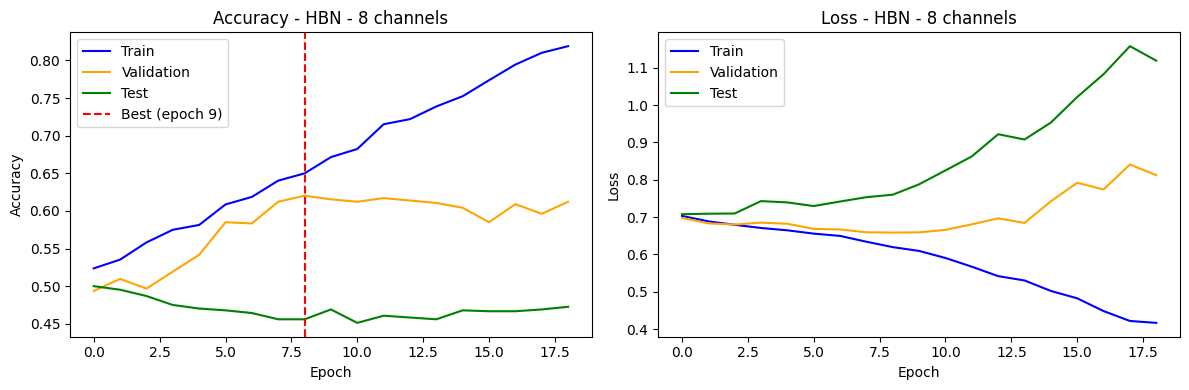


*** RESULTADO FINAL HBN - 8 canales ***
Mejor epoch: 9
Train en mejor epoch: 64.98%
Validation: 62.02%
Test en mejor epoch: 45.60%


In [ ]:
'''
Script de clasificación de matrices de conectividad funcional EEG mediante
una arquitectura CNN (Convolutional Neural Network).

Funciona con los siguientes datasets: PhysioNet, DS003766_v2, ds003490,
Schizophrenia, TUH y HBN.

Los notebooks de la carpeta `data_preparation/` se encargan de generar las
matrices de conectividad para cada dataset. La estructura esperada de
carpetas es:

    ConnectivityMatrices_<dataset>/
        Training/
            <canales>/
                <clase_0>/        # ej. T0, resting, CTL, HC, bckg, low
                    archivo1.npy
                    archivo2.npy
                    ...
                <clase_1>/        # ej. T1, task, PD, SZ, seiz, high
                    archivo1.npy
                    ...
        Test/
            <canales>/
                <clase_0>/
                <clase_1>/

Donde <canales> es uno de: 8, 16, 32, 64. TUH EEG, al tener solo 19 canales
originales, se evalúa únicamente con 8 y 16. Las matrices pueden estar en
formato .npy o .csv.

Antes del entrenamiento se aplica a cada matriz un preprocesado: se fuerza
la diagonal a 0, se anulan los valores por debajo de 0.1 y se normaliza.
División cross-subject: los sujetos de Test no aparecen en Training.
'''

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Variable
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

torch.set_grad_enabled(True)

# Define our CNN with the necessary layers
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, matrix_size=8):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        
        final_size = matrix_size // 4
        self.fc1 = nn.Linear(64 * final_size * final_size, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Function that retrieves the connectivity matrices from the folders and assigns their class
def load_data(folder_path, class_folders, label_fn):
    data_list = []

    for class_name in class_folders:
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                # Cargar .npy o .csv
                if file.endswith(".npy"):
                    filepath = os.path.join(class_path, file)
                    matrix_data = np.load(filepath)
                elif file.endswith(".csv"):
                    filepath = os.path.join(class_path, file)
                    df = pd.read_csv(filepath, index_col=0)
                    matrix_data = df.values
                else:
                    continue

                # Saltar si tiene NaN
                if np.isnan(matrix_data).any():
                    continue

                # Máscara: diagonal a 0
                np.fill_diagonal(matrix_data, 0)
                
                # Máscara: valores bajos a 0
                matrix_data[matrix_data < 0.1] = 0
                
                # Normalizar
                matrix_data = (matrix_data - matrix_data.mean()) / (matrix_data.std() + 1e-8)
                
                matrix_data = matrix_data.reshape(1, 1, matrix_data.shape[0], matrix_data.shape[1])
                data = torch.tensor(matrix_data, dtype=torch.float)
                label = label_fn(class_name)
                data.y = torch.tensor(label, dtype=torch.long)
                data_list.append(data)
    return data_list

# Función para evaluar
def evaluate(model, data, batch_size, criterion):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            batch_x = torch.cat([d for d in batch], dim=0)
            batch_y = torch.tensor([d.y.item() for d in batch], dtype=torch.long)
            
            out = model(batch_x)
            loss = criterion(out, batch_y)
            
            total_loss += loss.item() * len(batch)
            _, predicted = torch.max(out, 1)
            total_correct += (predicted == batch_y).sum().item()
            total_samples += len(batch)
    
    return total_loss / len(data), total_correct / total_samples

def train_and_plot_progress(model, train_data, val_data, test_data, optimizer, criterion, num_epochs, channel_config, dataset_name):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    test_losses = []
    test_accuracies = []

    # EARLY STOPPING
    best_val_acc = 0
    best_epoch = 0
    patience = 10
    epochs_without_improvement = 0
    best_model_state = None

    batch_size = 32

    for epoch in range(num_epochs):
        total_loss = 0
        total_correct = 0
        total_samples = 0

        model.train()

        for i in range(0, len(train_data), batch_size):
            batch = train_data[i:i+batch_size]
            batch_x = torch.cat([d for d in batch], dim=0)
            batch_y = torch.tensor([d.y.item() for d in batch], dtype=torch.long)
            
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(batch)
            _, predicted = torch.max(out, 1)
            total_correct += (predicted == batch_y).sum().item()
            total_samples += len(batch)

        train_loss = total_loss / len(train_data)
        train_acc = total_correct / total_samples
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        val_loss, val_acc = evaluate(model, val_data, batch_size, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        test_loss, test_acc = evaluate(model, test_data, batch_size, criterion)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        print(f'Epoch [{epoch + 1}/{num_epochs}] - Train: {train_acc*100:.2f}% | Val: {val_acc*100:.2f}% | Test: {test_acc*100:.2f}%')

        # EARLY STOPPING CHECK
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
        else:
            epochs_without_improvement += 1
        
        if epochs_without_improvement >= patience:
            print(f'\n*** Early stopping en epoch {epoch + 1} ***')
            print(f'Mejor validación: {best_val_acc*100:.2f}% en epoch {best_epoch}')
            break

    # Restaurar mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    epochs_run = len(train_accuracies)

    # Gráficas
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(epochs_run), train_accuracies, label='Train', color='blue')
    plt.plot(range(epochs_run), val_accuracies, label='Validation', color='orange')
    plt.plot(range(epochs_run), test_accuracies, label='Test', color='green')
    plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'Accuracy - {dataset_name} - {channel_config} channels')

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs_run), train_losses, label='Train', color='blue')
    plt.plot(range(epochs_run), val_losses, label='Validation', color='orange')
    plt.plot(range(epochs_run), test_losses, label='Test', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss - {dataset_name} - {channel_config} channels')

    plt.tight_layout()
    plt.savefig(f'results_{dataset_name}_{channel_config}channels.png')
    plt.show()
    
    print(f"\n*** RESULTADO FINAL {dataset_name} - {channel_config} canales ***")
    print(f"Mejor epoch: {best_epoch}")
    print(f"Train en mejor epoch: {train_accuracies[best_epoch-1]*100:.2f}%")
    print(f"Validation: {best_val_acc*100:.2f}%")
    print(f"Test en mejor epoch: {test_accuracies[best_epoch-1]*100:.2f}%")


# ============================================
# CONFIGURACIÓN
# ============================================
DATASET = "HBN"  # "PhysioNet", "DS003766_v2", "ds003490", "Schizophrenia", "HBN", "TUH"
channels = "8"       # Cambiar a "8", "16", "32", "64" (TUH solo 8 y 16)
num_epochs = 50

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Rutas según dataset
if DATASET == "PhysioNet":
    train_path = f"ConnectivityMatrices/Training/{channels}/"
    test_path = f"ConnectivityMatrices/Test/{channels}/"
    class_folders = ['T0', 'T1', 'T2']
    label_fn = lambda x: 0 if x == 'T0' else 1
elif DATASET == "DS003766_v2":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_DS003766_v2/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_DS003766_v2/Test/{channels}/"
    class_folders = ['resting', 'task']
    label_fn = lambda x: 0 if x == 'resting' else 1
elif DATASET == "ds003490":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_ds003490/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_ds003490/Test/{channels}/"
    class_folders = ['CTL', 'PD']
    label_fn = lambda x: 0 if x == 'CTL' else 1
elif DATASET == "Schizophrenia":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_Schizophrenia/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_Schizophrenia/Test/{channels}/"
    class_folders = ['HC', 'SZ']
    label_fn = lambda x: 0 if x == 'HC' else 1
elif DATASET == "TUH":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_TUH/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_TUH/Test/{channels}/"
    class_folders = ['bckg', 'seiz']
    label_fn = lambda x: 0 if x == 'bckg' else 1
elif DATASET == "HBN":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Test/{channels}/"
    class_folders = ['low', 'high']
    label_fn = lambda x: 0 if x == 'low' else 1

print(f"Dataset: {DATASET}")
print(f"Canales: {channels}")

# Cargar Training
print(f"\nCargando Training desde: {train_path}")
train_data_full = load_data(train_path, class_folders, label_fn)
random.shuffle(train_data_full)

# Dividir en Train (80%) + Validation (20%)
train_data, val_data = train_test_split(train_data_full, test_size=0.2, random_state=42)
print(f"  - {len(train_data)} train")
print(f"  - {len(val_data)} validation")

# Test separado
print(f"Cargando Test desde: {test_path}")
test_data = load_data(test_path, class_folders, label_fn)
random.shuffle(test_data)
print(f"  - {len(test_data)} test")

# Modelo - ajustar para ds003490 que tiene 63 canales en vez de 64
if DATASET == "ds003490" and channels == "64":
    matrix_size = 63
else:
    matrix_size = int(channels)

model = CNN(1, 2, matrix_size)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
criterion = nn.CrossEntropyLoss()

# Entrenar
train_and_plot_progress(model, train_data, val_data, test_data, optimizer, criterion, num_epochs, channels, DATASET)

Dataset: HBN
Canales: 8

Cargando Training desde: /home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Training/8/
  - 2496 train
  - 624 validation
Cargando Test desde: /home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Test/8/
  - 840 test
Epoch [1/50] - Train: 50.68% | Val: 53.21% | Test: 47.98%
Epoch [2/50] - Train: 52.88% | Val: 52.56% | Test: 48.93%
Epoch [3/50] - Train: 54.61% | Val: 55.93% | Test: 47.98%
Epoch [4/50] - Train: 55.89% | Val: 55.61% | Test: 47.26%
Epoch [5/50] - Train: 56.33% | Val: 54.33% | Test: 49.05%
Epoch [6/50] - Train: 55.61% | Val: 55.77% | Test: 49.52%
Epoch [7/50] - Train: 56.01% | Val: 54.97% | Test: 48.57%
Epoch [8/50] - Train: 55.49% | Val: 54.01% | Test: 48.57%
Epoch [9/50] - Train: 55.41% | Val: 53.85% | Test: 48.33%
Epoch [10/50] - Train: 55.13% | Val: 54.01% | Test: 49.17%
Epoch [11/50] - Train: 55.73% | Val: 56.41% | Test: 47.74%
Epoch [12/50] - Train: 55.37% | Val: 54.33% | Test: 49.76%
Epoch [13/50] - Train: 56.65% | Val

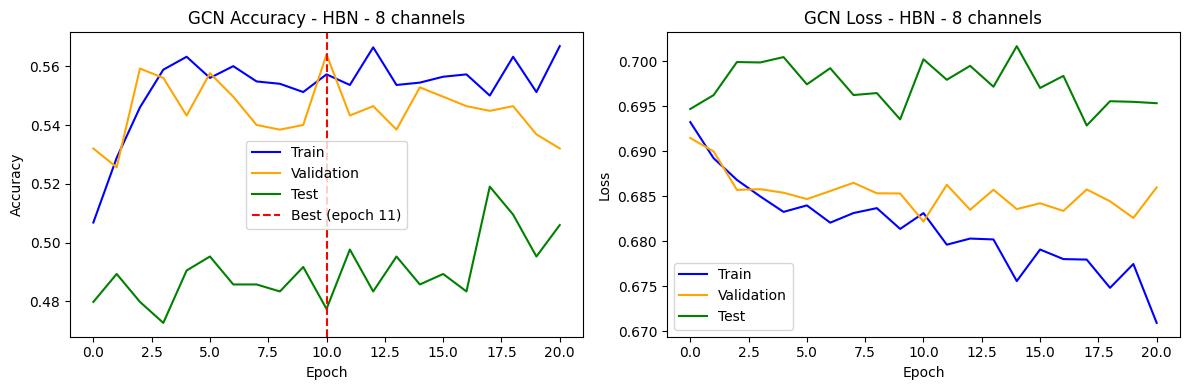


*** RESULTADO FINAL GCN HBN - 8 canales (SIN MÁSCARAS) ***
Mejor epoch: 11
Validation: 56.41%
Test en mejor epoch: 47.74%


In [ ]:
'''
Script de clasificación de matrices de conectividad funcional EEG mediante
Graph Convolutional Networks (GCN).

Funciona con los siguientes datasets: PhysioNet, DS003766_v2, ds003490,
Schizophrenia, TUH y HBN.

Los notebooks de la carpeta `data_preparation/` se encargan de generar las
matrices de conectividad para cada dataset. La estructura esperada de
carpetas es:

    ConnectivityMatrices_<dataset>/
        Training/
            <canales>/
                <clase_0>/        # ej. T0, resting, CTL, HC, bckg, low
                    archivo1.npy
                    archivo2.npy
                    ...
                <clase_1>/        # ej. T1, task, PD, SZ, seiz, high
                    archivo1.npy
                    ...
        Test/
            <canales>/
                <clase_0>/
                <clase_1>/

Donde <canales> es uno de: 8, 16, 32, 64. TUH EEG, al tener solo 19 canales
originales, se evalúa únicamente con 8 y 16. Las matrices pueden estar en
formato .npy o .csv.

El script carga las matrices, construye los grafos descartando las conexiones
débiles (threshold > 0.3) y entrena el modelo GCN. División cross-subject:
los sujetos de Test no aparecen en Training.
'''

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# PyTorch Geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool

# ============================================
# MODELO GCN
# ============================================
class GCN(nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, 64)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        x = global_mean_pool(x, batch)
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# ============================================
# CARGAR DATOS COMO GRAFOS - SIN MÁSCARAS
# ============================================
def load_data_as_graphs(folder_path, class_folders, label_fn, threshold=0.3):
    data_list = []

    for class_name in class_folders:
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                # Cargar .npy o .csv
                if file.endswith(".npy"):
                    filepath = os.path.join(class_path, file)
                    matrix = np.load(filepath)
                elif file.endswith(".csv"):
                    filepath = os.path.join(class_path, file)
                    df = pd.read_csv(filepath, index_col=0)
                    matrix = df.values
                else:
                    continue

                if np.isnan(matrix).any():
                    continue

                num_nodes = matrix.shape[0]
                
                # Crear edge_index SOLO donde supera threshold (estructura del grafo se mantiene)
                edge_index = []
                edge_attr = []
                
                for i in range(num_nodes):
                    for j in range(num_nodes):
                        if i != j and matrix[i, j] > threshold:
                            edge_index.append([i, j])
                            edge_attr.append(matrix[i, j])
                
                if len(edge_index) == 0:
                    continue
                
                edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
                edge_attr = torch.tensor(edge_attr, dtype=torch.float)
                
                # Node features = fila de la matriz normalizada
                matrix_norm = (matrix - matrix.mean()) / (matrix.std() + 1e-8)
                node_features = torch.tensor(matrix_norm, dtype=torch.float)
                
                label = label_fn(class_name)
                
                data = Data(
                    x=node_features,
                    edge_index=edge_index,
                    edge_attr=edge_attr,
                    y=torch.tensor(label, dtype=torch.long)
                )
                data_list.append(data)
    
    return data_list

# ============================================
# FUNCIONES DE ENTRENAMIENTO
# ============================================
def evaluate(model, data_list, criterion):
    model.eval()
    total_loss = 0
    total_correct = 0
    
    with torch.no_grad():
        for data in data_list:
            data.batch = torch.zeros(data.x.size(0), dtype=torch.long)
            out = model(data)
            loss = criterion(out, data.y.unsqueeze(0))
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            total_correct += (pred == data.y).sum().item()
    
    return total_loss / len(data_list), total_correct / len(data_list)

def train_and_plot_progress(model, train_data, val_data, test_data, optimizer, criterion, num_epochs, channel_config, dataset_name):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    test_losses = []
    test_accuracies = []

    best_val_acc = 0
    best_epoch = 0
    patience = 10
    epochs_without_improvement = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        total_correct = 0

        for data in train_data:
            data.batch = torch.zeros(data.x.size(0), dtype=torch.long)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, data.y.unsqueeze(0))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = out.argmax(dim=1)
            total_correct += (pred == data.y).sum().item()

        train_loss = total_loss / len(train_data)
        train_acc = total_correct / len(train_data)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        val_loss, val_acc = evaluate(model, val_data, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        test_loss, test_acc = evaluate(model, test_data, criterion)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        print(f'Epoch [{epoch + 1}/{num_epochs}] - Train: {train_acc*100:.2f}% | Val: {val_acc*100:.2f}% | Test: {test_acc*100:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
        else:
            epochs_without_improvement += 1
        
        if epochs_without_improvement >= patience:
            print(f'\n*** Early stopping en epoch {epoch + 1} ***')
            print(f'Mejor validación: {best_val_acc*100:.2f}% en epoch {best_epoch}')
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    epochs_run = len(train_accuracies)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(epochs_run), train_accuracies, label='Train', color='blue')
    plt.plot(range(epochs_run), val_accuracies, label='Validation', color='orange')
    plt.plot(range(epochs_run), test_accuracies, label='Test', color='green')
    plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'GCN Accuracy - {dataset_name} - {channel_config} channels')

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs_run), train_losses, label='Train', color='blue')
    plt.plot(range(epochs_run), val_losses, label='Validation', color='orange')
    plt.plot(range(epochs_run), test_losses, label='Test', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'GCN Loss - {dataset_name} - {channel_config} channels')

    plt.tight_layout()
    plt.savefig(f'results_GCN_{dataset_name}_{channel_config}channels.png')
    plt.show()
    
    print(f"\n*** RESULTADO FINAL GCN {dataset_name} - {channel_config} canales ***")
    print(f"Mejor epoch: {best_epoch}")
    print(f"Validation: {best_val_acc*100:.2f}%")
    print(f"Test en mejor epoch: {test_accuracies[best_epoch-1]*100:.2f}%")


# ============================================
# CONFIGURACIÓN
# ============================================
DATASET = "HBN"  # Cambiar a "PhysioNet" o "DS003766_v2" o "ds003490" o "Schizophrenia" o "TUH" o "HBN"
channels = "8"          # Cambiar a "8", "16", "32", "64" (TUH solo 8 y 16)
num_epochs = 50

seed = 42
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)

# Rutas según dataset
if DATASET == "PhysioNet":
    train_path = f"ConnectivityMatrices/Training/{channels}/"
    test_path = f"ConnectivityMatrices/Test/{channels}/"
    class_folders = ['T0', 'T1', 'T2']
    label_fn = lambda x: 0 if x == 'T0' else 1
elif DATASET == "DS003766_v2":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_DS003766_v2/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_DS003766_v2/Test/{channels}/"
    class_folders = ['resting', 'task']
    label_fn = lambda x: 0 if x == 'resting' else 1
elif DATASET == "ds003490":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_ds003490/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_ds003490/Test/{channels}/"
    class_folders = ['CTL', 'PD']
    label_fn = lambda x: 0 if x == 'CTL' else 1
elif DATASET == "Schizophrenia":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_Schizophrenia/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_Schizophrenia/Test/{channels}/"
    class_folders = ['HC', 'SZ']
    label_fn = lambda x: 0 if x == 'HC' else 1
elif DATASET == "TUH":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_TUH/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_TUH/Test/{channels}/"
    class_folders = ['bckg', 'seiz']
    label_fn = lambda x: 0 if x == 'bckg' else 1
elif DATASET == "HBN":
    train_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Training/{channels}/"
    test_path = f"/home/manu/TFG2/EEG-Gold-Standard-main/ConnectivityMatrices_HBN/Test/{channels}/"
    class_folders = ['low', 'high']
    label_fn = lambda x: 0 if x == 'low' else 1

print(f"Dataset: {DATASET}")
print(f"Canales: {channels}")

# Cargar datos
print(f"\nCargando Training desde: {train_path}")
train_data_full = load_data_as_graphs(train_path, class_folders, label_fn, threshold=0.3)
random.shuffle(train_data_full)

train_data, val_data = train_test_split(train_data_full, test_size=0.2, random_state=42)
print(f"  - {len(train_data)} train")
print(f"  - {len(val_data)} validation")

print(f"Cargando Test desde: {test_path}")
test_data = load_data_as_graphs(test_path, class_folders, label_fn, threshold=0.3)
random.shuffle(test_data)
print(f"  - {len(test_data)} test")

# Modelo GCN
# ajustar para ds003490 que tiene 63 canales
if DATASET == "ds003490" and channels == "64":
    num_node_features = 63
else:
    num_node_features = int(channels)
num_classes = 2
model = GCN(num_node_features, num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
criterion = nn.CrossEntropyLoss()

# Entrenar
train_and_plot_progress(model, train_data, val_data, test_data, optimizer, criterion, num_epochs, channels, DATASET)